# Conclusion

In this project, the Titanic dataset was analyzed using Python and Machine Learning.

Exploratory Data Analysis (EDA) was performed to understand passenger survival patterns.

Missing values were handled, unnecessary columns were removed, and categorical data was encoded.

Three machine learning models were trained:
- Logistic Regression
- Decision Tree
- Random Forest

Among all the models, Random Forest achieved the highest accuracy of **82.68%**, making it the best-performing model for this dataset.

This project demonstrates the complete machine learning workflow, from data preprocessing to model evaluation.

In [35]:
best_model = results.loc[results['Accuracy'].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model       Random Forest
Accuracy        82.681564
Name: 2, dtype: object


In [34]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy * 100,
        dt_accuracy * 100,
        rf_accuracy * 100
    ]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
2,Random Forest,82.681564
0,Logistic Regression,79.888268
1,Decision Tree,79.888268


In [33]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(random_state=42)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Accuracy: 82.68%


In [32]:
from sklearn.tree import DecisionTreeClassifier

# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train
dt_model.fit(X_train, y_train)

# Predict
dt_pred = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)

print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%")

Decision Tree Accuracy: 79.89%


In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [30]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[89 16]
 [20 54]]


In [29]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7988826815642458


In [28]:
# Predict on test data
y_pred = model.predict(X_test)

# Display first 10 predictions
print(y_pred[:10])

[0 0 0 1 1 1 1 0 1 1]


In [27]:
# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [25]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (712, 7)
Testing Data: (179, 7)


In [24]:
# Features (Input)
X = train_df.drop("Survived", axis=1)

# Target (Output)
y = train_df["Survived"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (891, 7)
Target Shape: (891,)


In [23]:
# Convert Sex column into numbers
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})

# Convert Embarked column into numbers
train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Display first 5 rows
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [22]:
train_df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [21]:
# Fill missing Embarked values with the most frequent value
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

In [20]:
train_df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [19]:
# Fill missing Age values with the median
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())

In [18]:
train_df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [17]:
# Drop unnecessary columns
train_df = train_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Display first 5 rows
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [16]:
# Check missing values again
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
plt.savefig("../images/fare_distribution.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

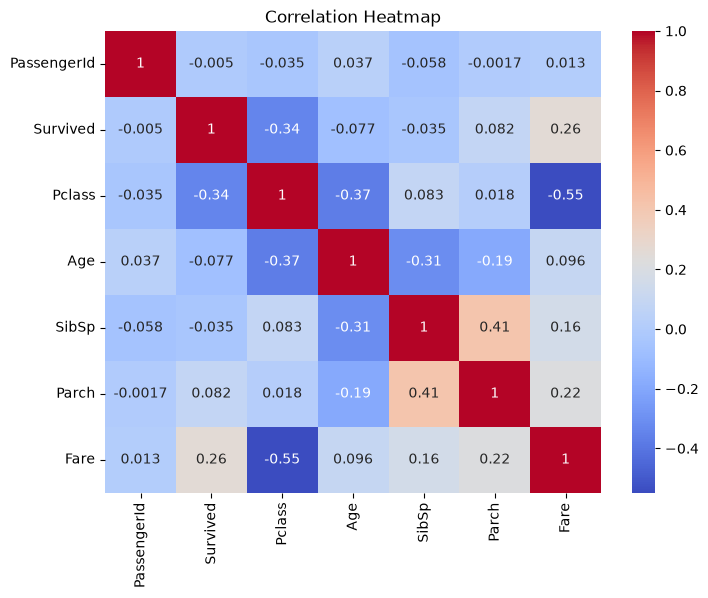

In [14]:
plt.figure(figsize=(8,6))

numeric_data = train_df.select_dtypes(include=['number'])

sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

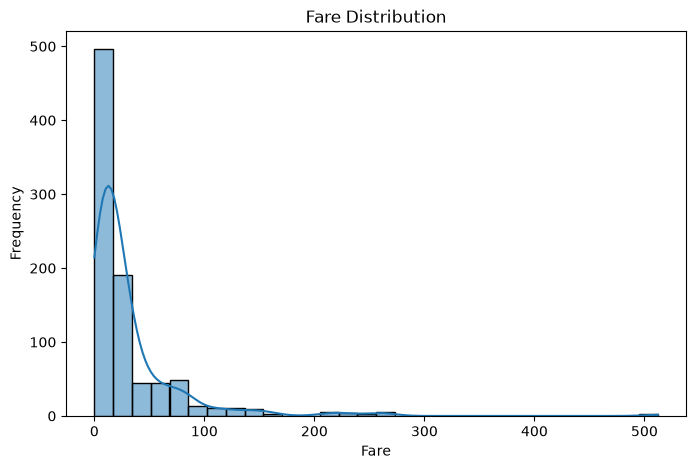

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(train_df['Fare'], bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

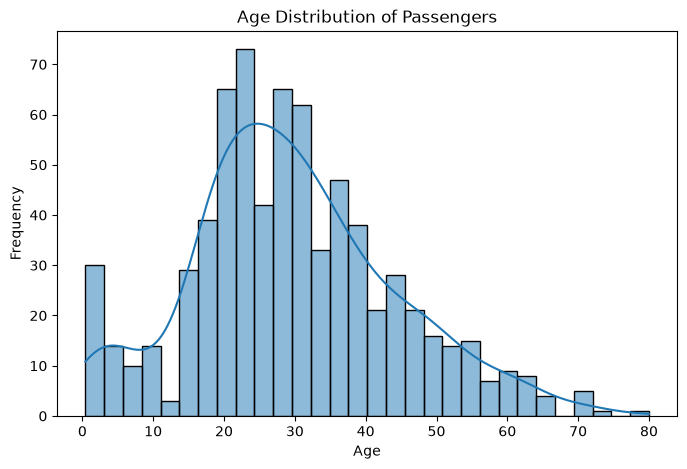

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(train_df['Age'], bins=30, kde=True)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

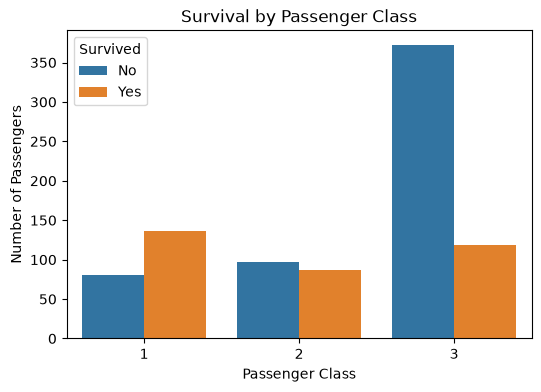

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x='Pclass', hue='Survived', data=train_df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

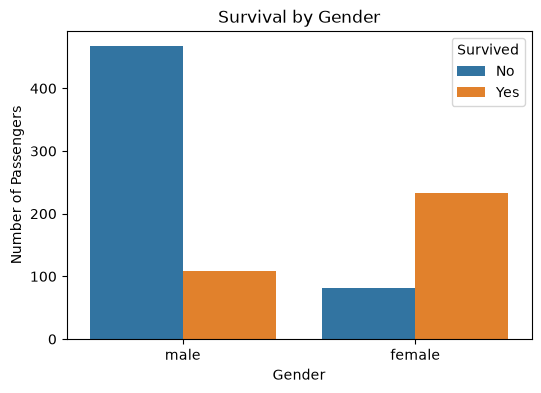

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x='Sex', hue='Survived', data=train_df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

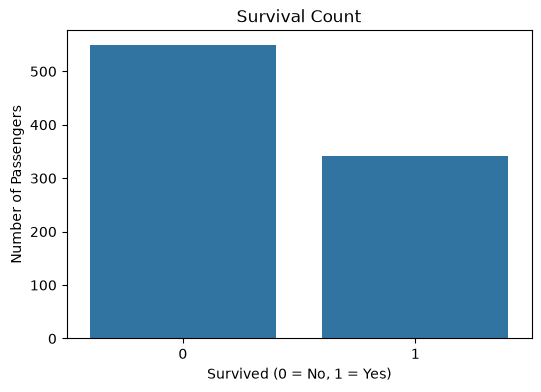

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x='Survived', data=train_df)

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

In [8]:
# Check for missing values
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# Statistical summary
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Basic information about the dataset
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Display column names
train_df.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [3]:
# Shape of the dataset
print("Shape of dataset:", train_df.shape)

Shape of dataset: (891, 12)


In [2]:
# Load the Titanic training dataset
train_df = pd.read_csv("../data/train.csv")

# Display the first 5 rows
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline